In [38]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import glob as gb
import cv2
from tensorflow.keras.models import load_model
from PIL import Image, ImageEnhance, ImageFilter  # Ensure Pillow is installed: `pip install Pillow`
# Get the current working directory
current_dir = os.getcwd()

# Go one step back
main_dir = os.path.dirname(current_dir)
model_path = os.path.join(main_dir, 'MODELS', 'trash_classifier_mobilenetv28.h5')
model = load_model(model_path)

In [39]:
code={"clean":0,"dirty":1}


def read_rgb888_from_file(file_path):
    """Reads RGB888 values from a text file and returns them as a NumPy array 96*96*3."""
    rgb888_values = []
    
    with open(file_path, 'r') as file:
        for line in file:
            rgb_values = line.strip().split()  # Split the line into RGB components
            if len(rgb_values) == 3:  # Check if there are 3 values (R, G, B)
                r = int(rgb_values[0])
                g = int(rgb_values[1])
                b = int(rgb_values[2])
                rgb888_values.append((r, g, b))  # Append tuple of RGB values
        rgb888_values=np.array(rgb888_values)    
        rgb888_values=rgb888_values.reshape(240, 240, 3)
    return np.array(rgb888_values, dtype=np.uint8)  # Ensure dtype is uint8 for image
def save_image_from_rgb888(rgb888_array, width, height, filename):
    """Saves the RGB888 array as an image file."""
    img_array = rgb888_array.reshape((height, width, 3))  # Reshape to (height, width, 3)
    img = Image.fromarray(img_array, 'RGB')
    
    # Rotate the image by 180 degrees
    img = img.rotate(180)

    # # Enhance image quality
    # img = enhance_image(img)

    # # Apply filter
    # img = apply_filters(img)

    img.save(filename)
    print(f"Image saved as {filename}")
from scipy.ndimage import median_filter

def enhance_img(img, brightness_factor=1.2, color_factor=1.5, sharpen=True, filter_size=3, apply_filter=True):
    """
    Enhances the brightness, color, sharpness of the image and applies a median filter if specified.

    Parameters:
    - img (numpy.ndarray): Input image as a NumPy array.
    - brightness_factor (float): Factor to enhance brightness. Default is 1.2 (20% brighter).
    - color_factor (float): Factor to enhance color saturation. Default is 1.5 (50% more saturation).
    - sharpen (bool): If True, applies a sharpening filter. Default is True.
    - filter_size (int): Size of the median filter. Default is 3 (3x3 filter).
    - apply_filter (bool): If True, applies the median filter. Default is True.
    
    Returns:
    - numpy.ndarray: Enhanced image.
    """
    
    # Convert NumPy array to Pillow Image
    img_pil = Image.fromarray(np.uint8(img))
    
    # Enhance the brightness
    if brightness_factor != 1.0:  # Only adjust if the factor is different from 1.0
        brightness_enhancer = ImageEnhance.Brightness(img_pil)
        img_pil = brightness_enhancer.enhance(brightness_factor)
    
    # Enhance the color saturation
    if color_factor != 1.0:  # Only adjust if the factor is different from 1.0
        color_enhancer = ImageEnhance.Color(img_pil)
        img_pil = color_enhancer.enhance(color_factor)
    
    # Convert Pillow Image to NumPy array for filtering
    img_filtered = np.array(img_pil)
    
    # Apply Median Filter if specified
    if apply_filter:
        img_filtered = median_filter(img_filtered, size=filter_size)
    
    # Convert back to Pillow Image
    img_filtered = Image.fromarray(np.uint8(img_filtered))

    # Apply sharpening filter if requested
    if sharpen:
        img_filtered = img_filtered.filter(ImageFilter.SHARPEN)
    
    # Convert Pillow Image back to NumPy array
    final_img_np = np.array(img_filtered)
    
    return final_img_np
def save_quantized_image_to_text(quantized_image, filename):
        """Saves the quantized RGB values of the image to a text file."""
        height, width, _ = quantized_image.shape
        with open(filename, 'w') as file:
            for y in range(height):
                for x in range(width):
                    r, g, b = quantized_image[y, x]
                    file.write(f"{r} {g} {b}\n")  # Write RGB values as space-separated strings
def normalize_image(image):
    """Normalize the image to range [-1, 1]."""
    image = image.astype(np.float32)  # Convert to float32 for division
    image = (image / 127.5) - 1.0  # Normalize to [-1, 1]
    return image
def convert_to_tflite_model(model, shuffled_x_test, output_model_path='model.tflite'):
    """
    Converts a Keras model to TFLite format with quantization.
    
    Args:
        model: The trained Keras model to be converted.
        shuffled_x_test: An array of test images to be used for quantization.
        output_model_path: The file path where the TFLite model will be saved.
    
    Returns:
        tflite_model: The converted TFLite model.
    """
    
    # Ensure x_test is in float32 format
    x_test_flat = tf.cast(shuffled_x_test, tf.float32)

    # Print shape to confirm
    print(f"x_test shape: {x_test_flat.shape}")  # Expected: (num_samples, 96, 96, 3)

    # Create a TensorFlow Dataset from the flattened test images
    xtest_ds = tf.data.Dataset.from_tensor_slices((x_test_flat)).batch(1)

    # Define a representative data generator for quantization
    def representative_data_gen():
        for input_value in xtest_ds.take(200):  # Taking up to 200 samples for representative data
            yield [input_value]

    # Example TFLite conversion with representative dataset
    converter = tf.lite.TFLiteConverter.from_keras_model(model)  # Assuming `model` is your trained model
    # Disable per-channel quantization for dense layers
    converter._experimental_disable_per_channel_quantization_for_dense_layers = True
    converter.representative_dataset = representative_data_gen
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.float32

    # Convert the model
    tflite_model = converter.convert()

    # Save the TFLite model
    with open(output_model_path, "wb") as f:
        f.write(tflite_model)

    print(f"TFLite model saved to {output_model_path}")
    return tflite_model
def plot_predictions(original_images, predicted_classes, prediction_scores):
    """
    Create a plot to display original images, their predictions, and model scores.
    
    Parameters:
        original_images (list of np.ndarray): List of original images in BGR format.
        predicted_classes (np.ndarray): Array of predicted classes (0 for clean, 1 for dirty).
        prediction_scores (np.ndarray): Array of prediction scores corresponding to each class.
    """
    num_images = len(predicted_classes)  # Total number of images predicted

    num_cols = min(num_images, 5)  # Set a max number of columns for better layout
    num_rows = (num_images + num_cols - 1) // num_cols  # Calculate number of rows needed

    # Create a figure for the plot
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3))

    # Flatten the axes array for easier iteration
    axes = axes.flatten() if num_rows > 1 else [axes]

    # Loop through the original images, predictions, and scores to display them
    for ax, original_image, prediction, score in zip(axes, original_images, predicted_classes, prediction_scores):
        # Show original image
        ax.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for displaying
        ax.axis('off')  # Hide axes

        # Determine predicted class
        label = "Clean" if prediction == 0 else "Dirty"
        score_str = f"{score:.2f}"  # Format the score to 2 decimal places

        # Set title with prediction and score
        ax.set_title(f"Pred: {label} (Score: {score_str})")

    # Hide any unused axes
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    # Adjust layout
    plt.tight_layout()
    plt.show()

In [40]:
test_path=os.path.join(main_dir,'dataset','test')
x_test = []
y_test = []

# Load and normalize testing data
for folder in os.listdir(test_path):
    images = gb.glob(pathname=test_path + '/' + folder + '/*')
    
    for img in images:
        try:
            image = cv2.imread(img)
            if image is not None:
                image = cv2.resize(image, (240, 240))  # Resize to (96, 96)
                image = normalize_image(image)  # Normalize to [-1, 1]
                x_test.append(image)
                y_test.append(code[folder])
        except Exception as e:
            print(f"Error loading image {img}: {e}")

In [41]:
x_test = np.array(x_test)
y_test = np.array(y_test)
indices = np.arange(x_test.shape[0])
np.random.shuffle(indices)
shuffled_x_test = x_test[indices]
shuffled_y_test = y_test[indices]

In [42]:
tf_model_paths=os.path.join(main_dir,"Models","TF_LITE_FinalModel4.tflite")
tflite_model = convert_to_tflite_model(model, shuffled_x_test,output_model_path=tf_model_paths)

x_test shape: (200, 240, 240, 3)
INFO:tensorflow:Assets written to: C:\Users\Lenovo\AppData\Local\Temp\tmptsdc6x6y\assets


INFO:tensorflow:Assets written to: C:\Users\Lenovo\AppData\Local\Temp\tmptsdc6x6y\assets


Saved artifact at 'C:\Users\Lenovo\AppData\Local\Temp\tmptsdc6x6y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 240, 240, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2115989650320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001122256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001123600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2115989650704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2115989648592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001122640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001121488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001121872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001122064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2116001123216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  211

d:\Smart bin\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:983: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite model saved to d:\Smart bin\Models\TF_LITE_FinalModel4.tflite


In [43]:
class TFLiteModel:
    def __init__(self, model_path: str):
        self.interpreter = tf.lite.Interpreter(model_path)
        self.interpreter.allocate_tensors()

        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

    def predict(self, *data_args):
        assert len(data_args) == len(self.input_details)
        for data, details in zip(data_args, self.input_details):
            self.interpreter.set_tensor(details["index"], data)
        self.interpreter.invoke()
        return self.interpreter.get_tensor(self.output_details[0]["index"])
    def preprocess_image(image_path):
        # Load image
        image = cv2.imread(image_path)
        # Resize to 96x96
        image = cv2.resize(image, (240, 240))
        # Normalize to [0, 1]
        image = normalize_image(image)
        # Quantize to int8
        scale = 0.007843137718737125
        zero_point = -1
        quantized_image = np.round(image / scale + zero_point).astype(np.int8)
        quantized_image = np.expand_dims(quantized_image, axis=0)  
        return quantized_image
    
   

In [44]:
tf_model_paths=os.path.join(main_dir,"Models","TF_LITE_FinalModel4.tflite")
tf_model=TFLiteModel(tf_model_paths)
tf_model.input_details

[{'name': 'serving_default_input_layer_5:0',
  'index': 0,
  'shape': array([  1, 240, 240,   3]),
  'shape_signature': array([ -1, 240, 240,   3]),
  'dtype': numpy.int8,
  'quantization': (0.007843137718737125, -1),
  'quantization_parameters': {'scales': array([0.00784314], dtype=float32),
   'zero_points': array([-1]),
   'quantized_dimension': 0},
  'sparsity_parameters': {}}]

In [45]:
#testing accuracy compared to the orignail model which was 96%
testAccImages=[]
testAccLabels=[]
# Quantize to int8
scale = 0.007843137718737125
zero_point = -1
for i in shuffled_x_test:
    quantized_image = np.round((i / scale) + zero_point).astype(np.int8)
    quantized_image=np.expand_dims(quantized_image, axis=0) 
    testAccImages.append(quantized_image)
for i in range(len(testAccImages)):
    testAccLabels.append((tf_model.predict(testAccImages[i])[0][0] >= 0.6).astype(int))
from sklearn.metrics import accuracy_score
acc=accuracy_score(shuffled_y_test,testAccLabels)
acc

0.965

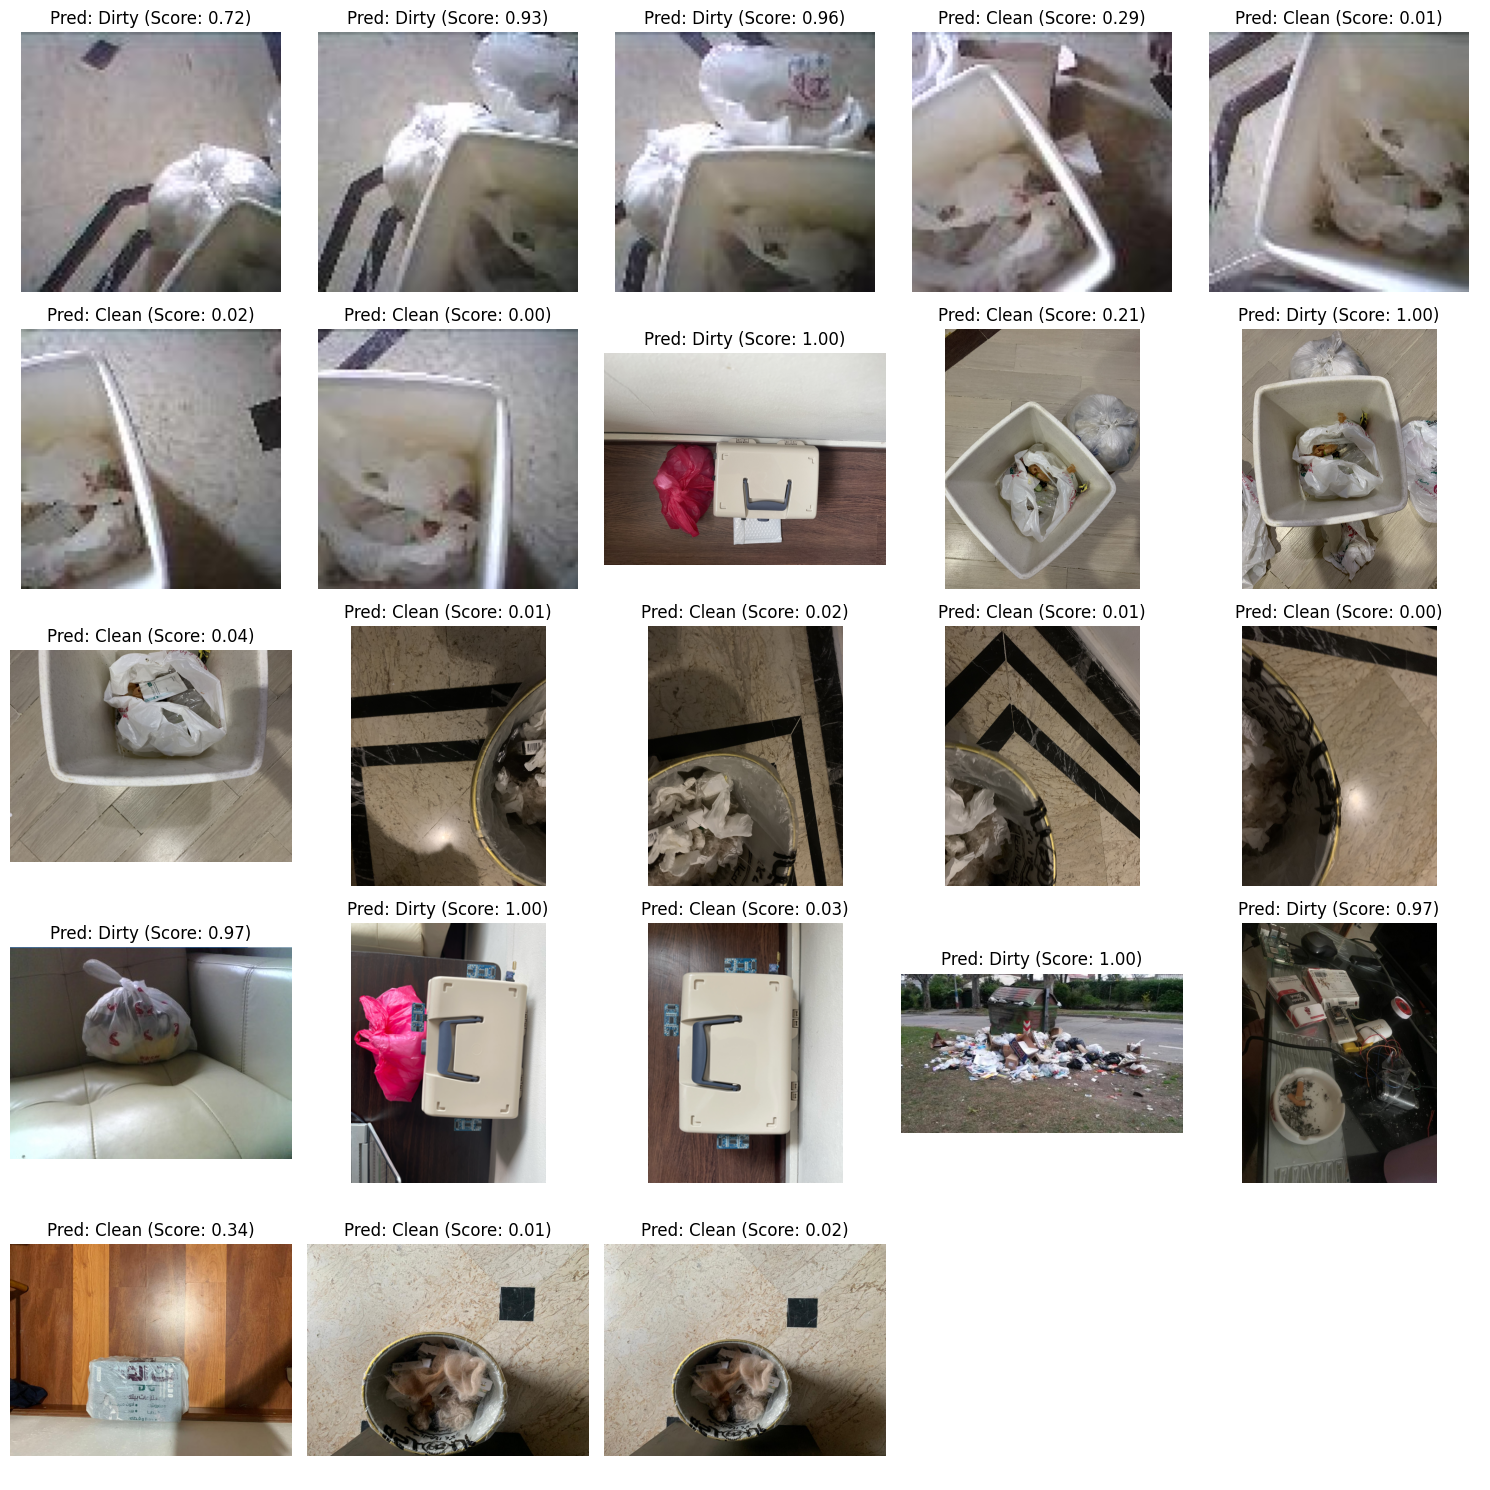

In [46]:
# Load and preprocess a multiple image
dir = main_dir+"/captured_images" #path to dir that has images
pred_images = []  # List to hold images for batch prediction
original_images = []  # List to hold original images
predicted_classes=[]
scores = []
predPaths = gb.glob(pathname=dir + '/*') #load all images from dir 

for img_path in predPaths:
  pred_images.append(TFLiteModel.preprocess_image(img_path))
  original_images.append(cv2.imread(img_path))

for i in range(len(pred_images)):
    scores.append(tf_model.predict(pred_images[i])[0][0])
    predicted_classes.append((tf_model.predict(pred_images[i]) >= 0.5).astype(int))
plot_predictions(original_images, predicted_classes,scores)

In [47]:
# Load and preprocess a single image
predicted_classes=[]
original_images=[]
score=[]
img_path = "D:\Smart bin\IMG_6849.jpeg" # Change to your image path
original_images.append(cv2.imread(img_path))
img=TFLiteModel.preprocess_image(img_path)
score.append(tf_model.predict(img)[0][0])
predicted_classes.append((tf_model.predict(img) >= 0.5).astype(int))
plot_predictions(original_images, predicted_classes,score)


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


In [11]:
# load and preprocess txt file sent from ESP32-cam
original_images=[]
score=[]
file_path = main_dir+'/tests/picture1_888.txt'  # Replace with the path to your text file
rgb888_array = read_rgb888_from_file(file_path)
rgb888_array=enhance_img(rgb888_array,brightness_factor=2.5,color_factor=1,apply_filter=True,sharpen=False,filter_size=1)
original_images.append(rgb888_array)
rgb888_array=normalize_image(rgb888_array)
scale = 0.007843137718737125
zero_point = -1
quantized_image = np.round(rgb888_array / scale + zero_point).astype(np.int8)
quantized_image = np.expand_dims(quantized_image, axis=0)
score.append(tf_model.predict(quantized_image)[0][0])
esp_pred=((tf_model.predict(quantized_image) >= 0.5).astype(int))
plot_predictions(original_images, esp_pred,score)


ValueError: cannot reshape array of size 27648 into shape (240,240,3)

In [ ]:
# load and preprocess quantized txt file sent from ESP32-cam
original_images=[]
score=[]
file_path = main_dir+'/tests/test1/picture5_Quantized.txt'  # Replace with the path to your qunatized text file
rgb888_array = read_rgb888_from_file(file_path)
original_images.append(rgb888_array)
rgb888_array = np.expand_dims(rgb888_array, axis=0)
rgb888_array=np.array(rgb888_array).astype('int8')
print(tf_model.predict(rgb888_array))
score.append(tf_model.predict(rgb888_array)[0][0])
esp_pred=((tf_model.predict(rgb888_array) >= 0.5).astype(int))
plot_predictions(original_images, esp_pred,score)